In [1]:
import pandas as pd
import xgboost
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')
import mlflow

## mlflow experimental setup

In [50]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/Users/theophilebaggio/Desktop/zoomcamp/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1', creation_time=1732261091882, experiment_id='1', last_update_time=1732261091882, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

## Read the data

In [51]:
categorical = ['PULocationID', 'DOLocationID']

def read_data(filename):
    df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)].copy()

    df[categorical] = df[categorical].astype('str')
    
    return df

df_train = read_data('data/yellow_tripdata_2023-01.parquet')
df_val = read_data('data/yellow_tripdata_2023-02.parquet')


## preprocess data

##### training data

In [52]:
train_dicts = df_train[categorical].to_dict(orient='records')
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
target = 'duration'
y_train = df_train[target].values


#### validation data

In [53]:
val_dicts = df_val[categorical].to_dict(orient='records')
X_val = dv.transform(val_dicts) 
y_val = df_val.duration.values

## training model

In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_train)
print(f'Train RMSE: {mean_squared_error(y_train, y_pred, squared=False)}')

Train RMSE: 7.649261932106969


## visualizing training data

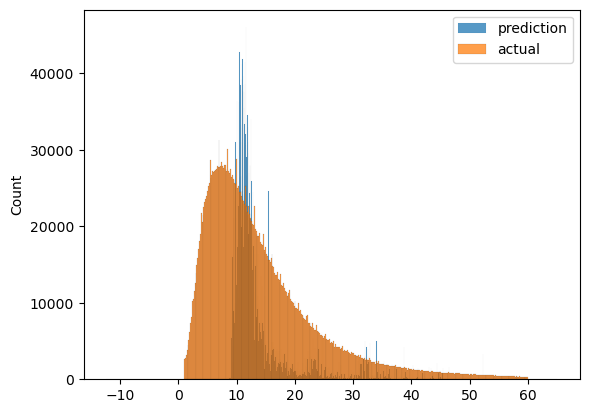

In [32]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend()
plt.show()

## validating model

In [33]:
y_pred = lr.predict(X_val)
print(f'Val RMSE: {mean_squared_error(y_val, y_pred, squared=False)}')

Val RMSE: 7.811818743246608


## visualizing validating data

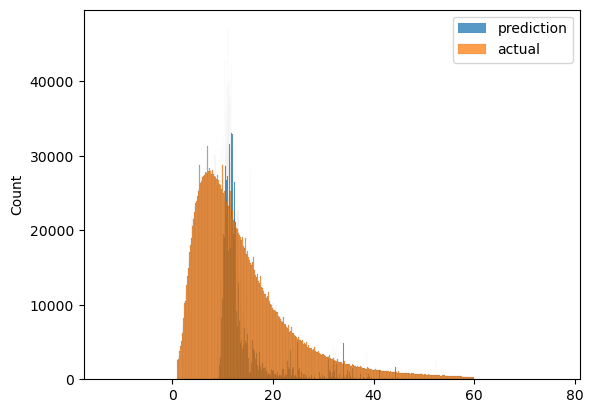

In [34]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend()
plt.show()

## Save the lr model and dv dict vectorizer 

In [35]:
with open("models/lin_reg.bin", "wb") as f_out:
    pickle.dump((dv,lr), f_out)

### Q7. Training a model with lasso regression, track the experiment (both results and the model versions):

In [36]:
# new run on mlflow:

with mlflow.start_run():

    mlflow.set_tag("developer", "Theo")
    mlflow.log_param("train-data-path", '/workspaces/mlops-zoomcamp/03-training/experiment_tracking/data/yellow_tripdata_2023-01.parquet')
    mlflow.log_param("valid-data-path", '/workspaces/mlops-zoomcamp/03-training/experiment_tracking/data/yellow_tripdata_2023-02.parquet')
    alpha = 0.01
    mlflow.log_param('alpha', alpha)
    
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_train)
    print(mean_squared_error(y_train, y_pred, squared=False))
    y_pred = lr.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)

    # model management:
    mlflow.log_artifact(local_path="models/lin_reg.bin",
                        artifact_path="models_pickle")
    

8.015544916926794


## MLFLOW TAKE A STEP IN

In [1]:
import pandas as pd
import xgboost
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')
import mlflow

In [2]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope
import xgboost as xgb
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/Users/theophilebaggio/Desktop/zoomcamp/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1', creation_time=1732261091882, experiment_id='1', last_update_time=1732261091882, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

## Read the data

In [3]:
categorical = ['PULocationID', 'DOLocationID']

def read_data(filename):
    df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)].copy()

    df[categorical] = df[categorical].astype('str')
    
    return df

df_train = read_data('data/yellow_tripdata_2023-01.parquet')
df_val = read_data('data/yellow_tripdata_2023-02.parquet')


## preprocess data

##### training data

In [4]:
train_dicts = df_train[categorical].to_dict(orient='records')
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
target = 'duration'
y_train = df_train[target].values


#### validation data

In [5]:
val_dicts = df_val[categorical].to_dict(orient='records')
X_val = dv.transform(val_dicts) 
y_val = df_val.duration.values

### define the datas for the xgboost model:

In [6]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

### objective we're tring to reach (model, params, data)

In [7]:
def objective(params, train, valid):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

#### hyperopt will search the parameters in a search space:

In [57]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 69
}



##### Launch hyperparametrization

In [ ]:
best_result = fmin(
    fn=lambda params: objective(params, train, valid),
    space=search_space,
    algo=tpe.suggest,
    max_evals=5,
    trials=Trials(),
    
)

##### we can use mlflow.autolog:

In [ ]:
best_params = {
        'learning_rate': 0.08901221861380557,
        'max_depth': 38,
        'min_child_weight': 0.7777716967894652,
        'objective': 'reg:linear',
        'reg_alpha': 0.04057481649042713,
        'reg_lambda': 0.2962048142157826,
        'seed': 69
    }

mlflow.xgboost.autolog()

booster = xgb.train(
            params=best_params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=20
        )

### Model management:

In [ ]:
with mlflow.start_run():
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.08901221861380557,
        'max_depth': 38,
        'min_child_weight': 0.7777716967894652,
        'objective': 'reg:linear',
        'reg_alpha': 0.04057481649042713,
        'reg_lambda': 0.2962048142157826,
        'seed': 69
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=400,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)

    # save preprocessor (here: dictVectorizer)
    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact("models/preprocessor.b", artifact_path='preprocessor')

    # save model
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

### Load a model from a mlflow run:

In [8]:
logged_model = 'runs:/c7617d2f80304405af3cfcba81e7cdf0/models_mlflow'
xg_boost_model = mlflow.xgboost.load_model(logged_model)


In [ ]:
xg_boost_model.

In [9]:
y_pred = xg_boost_model.predict(valid[1:10])
print(y_pred)

### Get models from modelp registry of mlflow

In [68]:
from mlflow.tracking import MlflowClient

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)


In [32]:
client.search_experiments()

[<Experiment: artifact_location='/workspaces/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1', creation_time=1725634597237, experiment_id='1', last_update_time=1725634597237, lifecycle_stage='active', name='nyc_taxi_experiment', tags={}>,
 <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1725634238852, experiment_id='0', last_update_time=1725634238852, lifecycle_stage='active', name='Default', tags={}>]

In [42]:
from mlflow.entities import ViewType
runs = client.search_runs(
    experiment_ids='1',
    filter_string="metrics.rmse > 5.38",
    run_view_type= ViewType.ACTIVE_ONLY,
    order_by=['metrics.rmse ASC'],
    max_results=4
)

In [43]:
for run in runs:
    print(f"run id: {run.info.run_id}, rmse: {run.data.metrics['rmse']:.4f}")

run id: 2d384f45bc104dd6b885e71be3612efa, rmse: 5.3832
run id: a19b1102b5034b7da4d8b4369ca6c3fe, rmse: 5.3832
run id: 620520bcb41b4d249e560b0452e7ed0c, rmse: 5.4076
run id: c5f53f5ee825478189d018a13cec431a, rmse: 6.4798


In [39]:
import mlflow
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI) 

In [45]:
run_id = "2d384f45bc104dd6b885e71be3612efa"
model_uri = f"runs:/{run_id}/model"
model name = 
mlflow.register_model(model_uri=model_uri, name= "NYC-Taxi-Regressor")

Successfully registered model 'nyc_taxi_regressor'.
Created version '1' of model 'nyc_taxi_regressor'.


<ModelVersion: aliases=[], creation_timestamp=1726059488121, current_stage='None', description=None, last_updated_timestamp=1726059488121, name='nyc_taxi_regressor', run_id='2d384f45bc104dd6b885e71be3612efa', run_link=None, source='/workspaces/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1/2d384f45bc104dd6b885e71be3612efa/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=1>

In [71]:
model_name = "NYC-Taxi-Predictor"
client.get_model_version_by_alias(model_name, "champion")


<ModelVersion: aliases=['champion'], creation_timestamp=1726061029367, current_stage='None', description='', last_updated_timestamp=1726061029367, name='NYC-Taxi-Predictor', run_id='eb5354e5e26540bcbccfffde4b9a4c8e', run_link='', source='/workspaces/mlops-zoomcamp/03-training/experiment_tracking/mlruns/1/eb5354e5e26540bcbccfffde4b9a4c8e/artifacts/models_mlflow', status='READY', status_message=None, tags={'model': 'xgboost', 'validation_status': 'approved'}, user_id=None, version=2>

### Simulate a model selection for a model in mlflow model registry:

In [28]:
from sklearn.metrics import root_mean_squared_logmean_squared_error
import pandas as pd
import mlflow
from mlflow.tracking import MlflowClient

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

def read_dataframe(filename):
    df = pd.read_parquet(filename)
    #print(df.columns)
    df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
    df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df


def preprocess(df, dv):
    df['PU_DO'] = df['PULocationID'] + '_' + df['DOLocationID']
    categorical = ['PU_DO']
    numerical = ['trip_distance']
    train_dicts = df[categorical + numerical].to_dict(orient='records')
    return dv.transform(train_dicts)


def test_model(name, alias, X_test, y_test):

    model = mlflow.pyfunc.load_model(f"models:/{name}@{alias}")

    #model = mlflow.pyfunc.load_model(model_uri = f"models:/{name}/{version}")
    y_pred = model.predict(X_test)
    return {"rmse": mean_squared_error(y_test, y_pred, squared=False)}



In [11]:
df = read_dataframe('/workspaces/mlops-zoomcamp/03-training/experiment_tracking/data/yellow_tripdata_2023-03.parquet')

In [13]:
run_id = "eb5354e5e26540bcbccfffde4b9a4c8e"
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
client.download_artifacts(run_id=run_id, path='preprocessor', dst_path='.')


'/workspaces/mlops-zoomcamp/03-training/experiment_tracking/preprocessor'

In [14]:
import pickle

with open("preprocessor/preprocessor.b", "rb") as f_in:
    dv = pickle.load(f_in)
    
X_test = preprocess(df, dv)
target = "duration"
y_test = df[target].values

In [29]:


model_name="NYC-Taxi-Predictor"
alias = "champion"
version=2
%time test_model(name=model_name, alias=alias, X_test=X_test, y_test=y_test)


CPU times: user 12min 22s, sys: 1.01 s, total: 12min 23s
Wall time: 6min 39s


/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'rmse': np.float64(10.782672441606053)}

In [30]:
mlflow.get_tracking_uri()

'sqlite:///mlflow.db'